# Method 28 - Polar stereographic projection, 95th percentile random sampling overflow bins

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.mixture import GaussianMixture
from funcs import profileNo_vs_xy_bins, sample_cap_bins_xy, plot_geo, plot_heatmap_npts_xy

In [ ]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

In [ ]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [ ]:
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']

In [ ]:
threshold = profileNo_vs_xy_bins(df_ST, n_x_bins=100, n_y_bins=100, show_threshold=True, threshold_quantile=0.95, projection='npstere')

In [ ]:
print(threshold)

10671


In [ ]:
df_sampled = sample_cap_bins_xy(df_ST, thresh=threshold, n_x_bins=100, n_y_bins=100)

In [ ]:
_ = profileNo_vs_xy_bins(df_sampled, n_x_bins=100, n_y_bins=100, show_threshold=False, threshold_quantile=0.95, projection='npstere')

## Four clusters to compare methods

In [ ]:
# Four clusters for comparison of methods
n_clusters = 4

In [ ]:
gmm = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [ ]:
df_sampled['gmm_label_4'] = labels

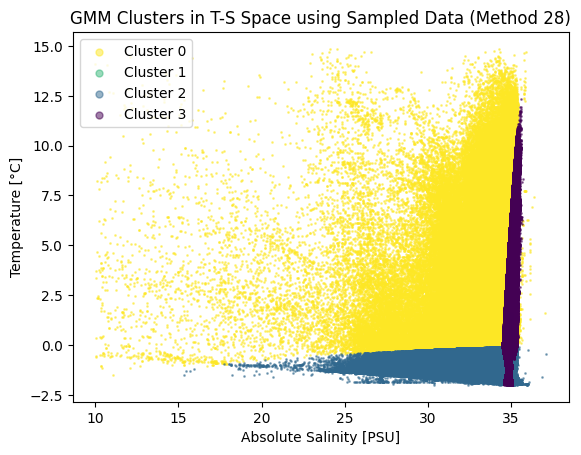

In [ ]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_4'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 28)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

In [ ]:
# Sample geographically for better plotting
df_sampled_plot = df_sampled.sample(n=70000, random_state=seed)
plot_geo(df_sampled_plot, n_clusters=4)

## Distribution

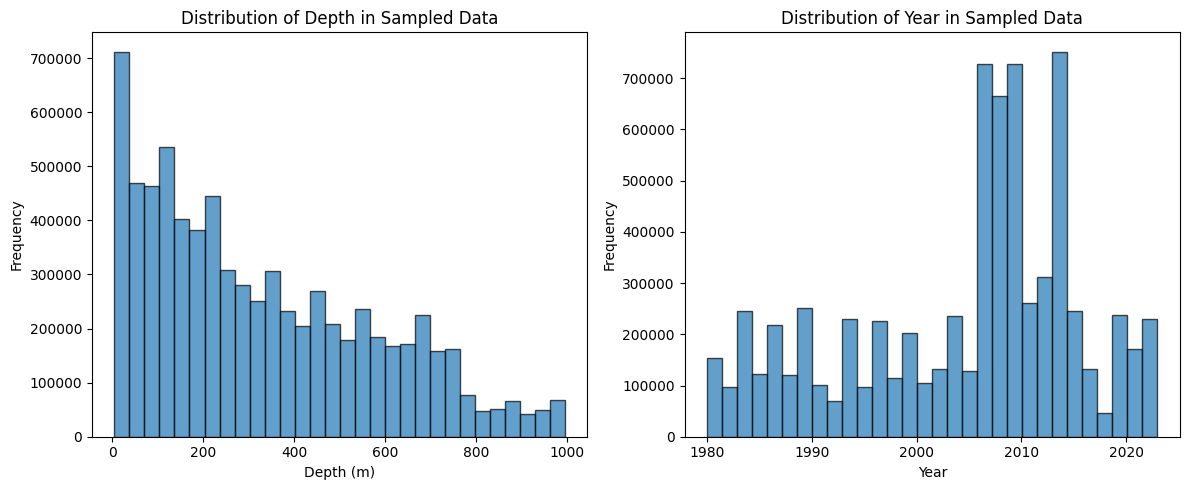

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df_sampled['Depth_[m]'], bins=30, edgecolor='black', alpha=0.7) 
plt.xlabel('Depth (m)')
plt.ylabel('Frequency')
plt.title('Distribution of Depth in Sampled Data')
plt.subplot(1, 2, 2)
plt.hist(df_sampled['year'], bins=30, edgecolor='black', alpha=0.7)    
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Distribution of Year in Sampled Data')
plt.tight_layout()
plt.show()

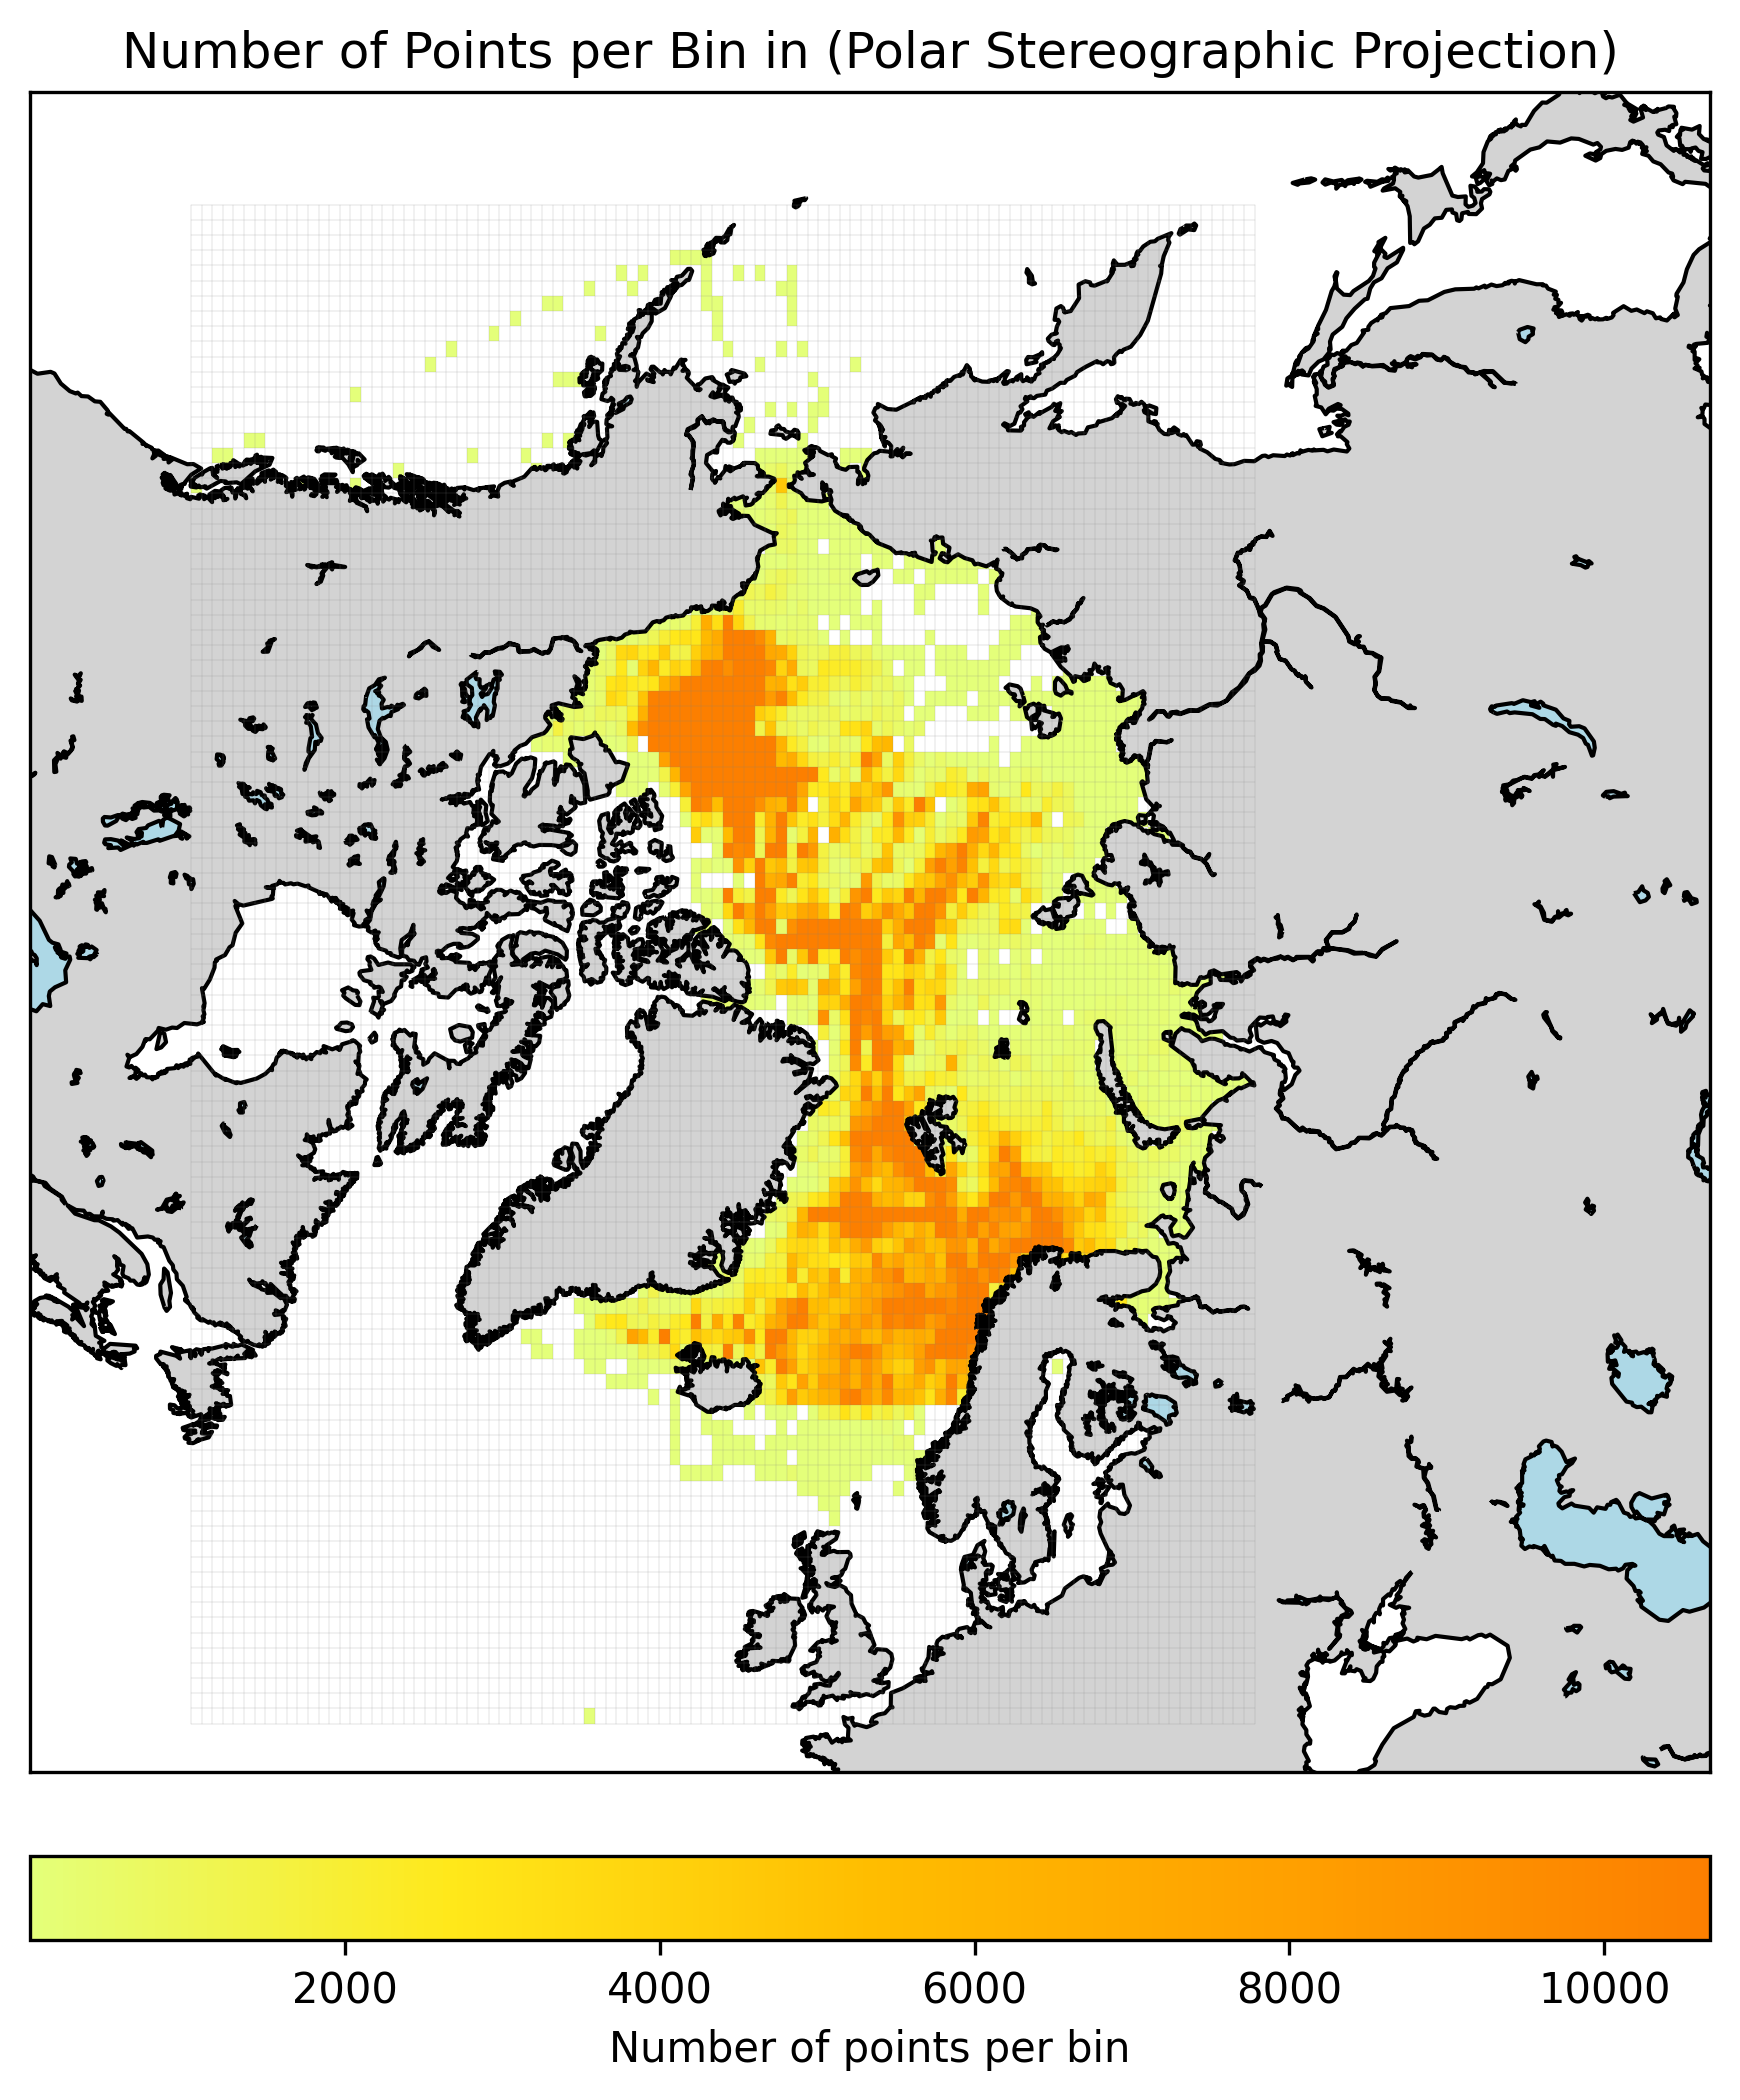

In [ ]:
plot_heatmap_npts_xy(df_sampled, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic')

## BIC score

In [ ]:
# Define random seed for reproducibility
seed = 22
random.seed(seed)

In [ ]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
    gmm.fit(df_sampled[features])
    bic_scores.append(gmm.bic(df_sampled[features]))

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components')

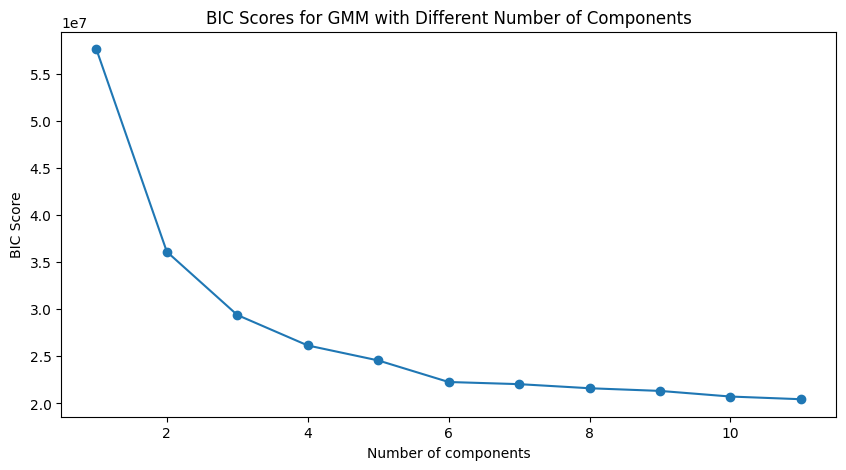

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components')

In [ ]:
# Choice of optimal number of clusters based on BIC
optimal_n_components = 6

In [ ]:
gmm = GaussianMixture(
    n_components=optimal_n_components,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seed)

labels = gmm.fit_predict(df_sampled[features])

In [ ]:
df_sampled['gmm_label'] = labels

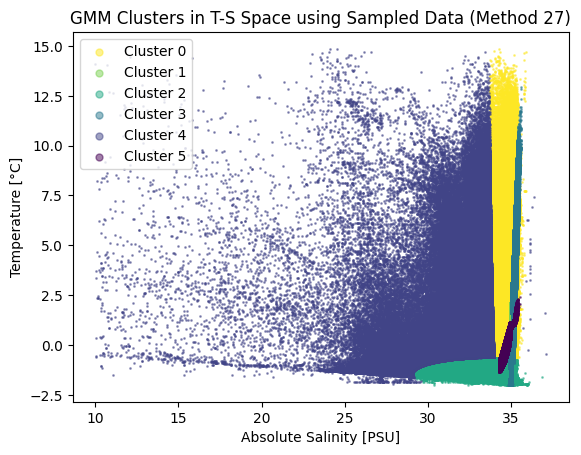

In [ ]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, optimal_n_components))

for i in range(optimal_n_components):
    mask = df_sampled['gmm_label'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 28)")
plt.legend(loc='upper left', markerscale=5)
plt.show()